In [332]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear
import pandas as pd
from scipy.linalg import lstsq
from sklearn.model_selection import train_test_split
import cvxpy as cp

In [333]:
def train(q_hp, delta_T_i, delta_T_a, q_solar, idx_night, delta_t):
    N = len(delta_T_i)
    
    # Expression
    X1 = delta_T_a*delta_t
    X2 = q_hp
    X3 = idx_night
    X4 = q_solar 
    
    Y_n = delta_T_i
     
    X_n = np.column_stack([X1, X2, X3, X4])
    lb = [0.0, 0.0, -np.inf, 0.0]
    ub = [ np.inf,  np.inf, np.inf, np.inf]

    res = lsq_linear(X_n, Y_n, bounds=(lb, ub))

    theta_n = res.x
    residuals_n = res.cost * 2   # lsq_linear reports 1/2 ||r||^2

    # recover parameters
    alpha, beta, gamma, epsilon = theta_n   # [1/(C·R), 1/C, w_n/C]
    C     = 1.0 / beta
    R_a   = beta / alpha
    w_n   = gamma * C
    eta_s   = epsilon * C
    rmse_n  = np.sqrt(residuals_n / len(Y_n))

    return C, R_a, w_n, eta_s, rmse_n

In [334]:
def train_last_chance(q_hp, delta_T_i, delta_T_a, q_solar, idx_night, delta_t):
    N = len(delta_T_i)
    
    # Expression
    X1 = delta_T_a*delta_t
    X2 = q_hp
    X3 = idx_night
    X4 = q_solar 
    
    Y_n = delta_T_i
     
    X_n = np.column_stack([X1, X2, X3, X4])
    lb = [0.0, 0.0, -np.inf, -np.inf]
    ub = [ np.inf,  np.inf, np.inf, np.inf]

    res = lsq_linear(X_n, Y_n, bounds=(lb, ub))

    theta_n = res.x
    residuals_n = res.cost * 2   # lsq_linear reports 1/2 ||r||^2

    # recover parameters
    alpha, beta, gamma, epsilon = theta_n   # [1/(C·R), 1/C, w_n/C]
    C     = 1.0 / beta
    R_a   = beta / alpha
    w_n   = gamma * C
    eta_s   = epsilon * C
    rmse_n  = np.sqrt(residuals_n / len(Y_n))

    return C, R_a, w_n, eta_s, rmse_n

In [335]:
def year_windows_from_first_ts(first_ts: pd.Timestamp):
    """
    Calendar-year window:
    - Year starts Jan 1 of first_ts.year
    - Training window is Jan 1 – Mar 31
    - Year ends Dec 31
    """
    year = first_ts.year + 1

    year_start = pd.Timestamp(year=year, month=1, day=1)
    train_end  = pd.Timestamp(year=year, month=3, day=31, hour=23, minute=59, second=59)
    year_end   = pd.Timestamp(year=year, month=12, day=31, hour=23, minute=59, second=59)

    return year_start, train_end, year_end


In [336]:
def clean_and_gate_house_year(
    df_single: pd.DataFrame,
    t_start: pd.Timestamp,
    t_train_end: pd.Timestamp,
    t_year_end: pd.Timestamp,
    # columns to gate on
    col_Ti: str = "Internal_Air_Temperature",
    col_qhp: str = "Heat_Pump_Energy_Output",
    # sampling / interpolation behavior
    enforce_freq: str | None = "30min",   # set None to avoid forcing a grid
    max_gap_steps: int = 4,               # 4*30min = 2 hours
    do_interpolate: bool = True,
    # missingness thresholds (tune)
    max_missing_year: float = 0.90,       # allow up to 90% missing in year #
        # window
    max_missing_train: float = 0.20,      # allow up to 10% missing in 
        # training window
    # minimum data requirements (optional but useful)
    min_train_points: int = 1000,         # for 30-min data ~ 21 days; tune as needed
    verbose: bool = False,
):
    diag = {}

    # 0) Ensure datetime index
    if "Timestamp" in df_single.columns:
        df = df_single.copy()
        df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
        df = df.dropna(subset=["Timestamp"]).set_index("Timestamp").sort_index()
    else:
        # already indexed by timestamp
        df = df_single.copy()
        df.index = pd.to_datetime(df.index, errors="coerce")
        df = df.dropna(subset=[col_Ti, col_qhp], how="all").sort_index()

    # 1) Slice to chosen year window
    df_year = df.loc[(df.index >= t_start) & (df.index <= t_year_end)].copy()
    if df_year.empty:
        diag.update({"reason": "empty_year_window", "n_year_rows": 0})
        return None, None, diag

    # 2) Optionally regularize to a strict grid *after* slicing
    # (do this here so you don't manufacture NaNs outside the target window)
    if enforce_freq is not None:
        # round to grid, merge duplicates, then resample
        df_year.index = df_year.index.round(enforce_freq)
        df_year = df_year.groupby(df_year.index).mean(numeric_only=True)
        df_year = df_year.resample(enforce_freq).mean()

    # 3) Training slice (Jan–Mar of the selected year)
    df_train = df_year.loc[(df_year.index >= t_start) & (df_year.index <= t_train_end)].copy()
    if df_train.empty:
        diag.update({"reason": "no_data_in_training_window", "n_train_rows": 0, "n_year_rows": len(df_year)})
        return None, None, diag

    # 4) Missingness BEFORE interpolation (only on the gating columns)
    req_cols = [c for c in [col_Ti, col_qhp] if c in df_year.columns]
    if len(req_cols) < 2:
        diag.update({"reason": "missing_required_columns", "required_cols_present": req_cols})
        return None, None, diag

    miss_year = df_year[req_cols].isna().mean().to_dict()
    miss_train = df_train[req_cols].isna().mean().to_dict()

    diag.update({
        "n_year_rows": len(df_year),
        "n_train_rows": len(df_train),
        "miss_year_before": miss_year,
        "miss_train_before": miss_train,
    })

    # 5) Gate: if too much missing data, skip this house
    if (max(miss_train.values()) > max_missing_train):
        diag["reason"] = "missingness_threshold_exceeded"
        return None, None, diag

    # 6) Interpolate short gaps (numeric only), then drop remaining NaNs in required cols
    df_filled = df_year.copy()
    if do_interpolate:
        num_cols = df_filled.select_dtypes(include=["number"]).columns
        df_filled[num_cols] = df_filled[num_cols].interpolate(
            method="time",
            limit=max_gap_steps,
            limit_direction="both",
        )

    df_year_clean = df_filled.dropna(subset=req_cols).copy()
    df_train_clean = df_year_clean.loc[(df_year_clean.index >= t_start) & (df_year_clean.index <= t_train_end)].copy()

    diag.update({
        "n_year_rows_clean": len(df_year_clean),
        "n_train_rows_clean": len(df_train_clean),
        "miss_year_after": df_year_clean[req_cols].isna().mean().to_dict(),  # should be zeros
        "miss_train_after": df_train_clean[req_cols].isna().mean().to_dict(),
    })

    # 7) Minimum training points check (optional)
    if len(df_train_clean) < min_train_points:
        diag["reason"] = "too_few_training_points"
        return None, None, diag

    diag["reason"] = "ok"
    if verbose:
        print(diag)

    return df_year_clean, df_train_clean, diag

In [337]:
df_train_detached = pd.read_parquet("retrieved_weather_data/merged_data_final_homes.parquet")
type(df_train_detached)
df_train_detached

,Unnamed: 0,Property_ID,Timestamp,half-hour,Boiler_Energy_Output,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,...,Brine_Return_Temperature,Postcode,Postcode_Timestamp,temp,humidity,windspeed,solarradiation,pressure,visibility,cloudcover
0,0,EOH0005,2021-05-21 12:00:00,12:00:00,NaN,0.003,NaN,0.240,8.67,NaN,...,NaN,EH33,EH33_2021-05-21 12:00:00,9.0,94.430,26.30,84.0,990.40,5.90,96.00
1,1,EOH0005,2021-05-21 12:30:00,12:30:00,NaN,0.020,NaN,1.782,8.58,NaN,...,NaN,EH33,EH33_2021-05-21 12:30:00,9.0,94.180,26.90,77.0,990.70,6.00,96.05
2,2,EOH0005,2021-05-21 13:00:00,13:00:00,NaN,0.036,NaN,1.852,8.50,NaN,...,NaN,EH33,EH33_2021-05-21 13:00:00,9.0,93.930,27.50,70.0,991.00,6.10,96.10
3,3,EOH0005,2021-05-21 13:30:00,13:30:00,NaN,0.038,NaN,2.466,8.50,NaN,...,NaN,EH33,EH33_2021-05-21 13:30:00,8.9,93.535,26.40,67.5,991.30,6.70,92.90
4,4,EOH0005,2021-05-21 14:00:00,14:00:00,NaN,0.038,2.514,3.323,8.52,NaN,...,NaN,EH33,EH33_2021-05-21 14:00:00,8.8,93.140,25.30,65.0,991.60,7.30,89.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11113027,11113027,EOH3204,2023-03-10 09:00:00,09:00:00,NaN,NaN,NaN,NaN,2.96,NaN,...,NaN,RH18,RH18_2023-03-10 09:00:00,3.5,92.570,24.30,67.0,991.90,5.90,100.00
11113028,11113028,EOH3204,2023-03-10 09:30:00,09:30:00,NaN,NaN,NaN,NaN,2.73,NaN,...,NaN,RH18,RH18_2023-03-10 09:30:00,3.2,91.205,25.05,89.5,993.55,11.45,99.70
11113029,11113029,EOH3204,2023-03-10 10:00:00,10:00:00,NaN,NaN,NaN,NaN,2.83,NaN,...,NaN,RH18,RH18_2023-03-10 10:00:00,2.9,89.840,25.80,112.0,995.20,17.00,99.40
11113030,11113030,EOH3204,2023-03-10 10:30:00,10:30:00,NaN,NaN,NaN,NaN,3.31,NaN,...,NaN,RH18,RH18_2023-03-10 10:30:00,3.2,86.745,26.90,163.0,996.55,31.30,99.70


In [338]:
unique_ids = df_train_detached["Property_ID"].unique()

df_house = pd.read_csv('training_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual","HP_Size_kW",
    "HP_Installed", "House_SAP"
]

df_house_train = {}
for id_use in unique_ids:
    df_house_train[id_use] = df_house[df_house["Property_ID"] == id_use]

In [339]:
missing_counts = df_house[df_house["Property_ID"].isin(unique_ids)][["Floor_Height", "Total_Floor_Area"]].isna().sum()
print(missing_counts)


Floor_Height        20
Total_Floor_Area     0
dtype: int64


In [340]:
df_single = df_train_detached[
        df_train_detached["Property_ID"] == id_use].copy()

range_df_hp = (df_single .dropna(subset=["Heat_Pump_Energy_Output"]) .groupby("Property_ID")["Timestamp"] .agg(first_available="min", last_available="max") )

In [341]:
trained_params = pd.DataFrame(index=["Floor Area", "No_Storeys", "Wall_Type",
                                     "HP_Type", "House_SAP",
                                     "C", "R_a", "w_s", "w_n",
                                     "rmse", "train_start", "train_end",
                                     "val_start", "val_end"])


j = 0
for id_use in unique_ids:
    j = 1
    id_use = 'EOH2034'
    wall = df_house_train[id_use].Wall_Type.to_string()
    storeys = df_house_train[id_use].No_Storeys.to_string()
    floor_area = df_house_train[id_use].Total_Floor_Area.to_string()
    hp_type = df_house_train[id_use].HP_Installed.to_string()
    house_sap = df_house_train[id_use].House_SAP.to_string()

    df_single = df_train_detached[
        df_train_detached["Property_ID"] == id_use].copy()

    df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
        "Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single[
        "Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] -
         df_single["Internal_Air_Temperature"])

    range_df_hp = (df_single.dropna(subset=["Heat_Pump_Energy_Output"]) .groupby("Property_ID")["Timestamp"] .agg(first_available="min", last_available="max") )
    first_ts = range_df_hp["first_available"].iloc[0]
    t_start, t_train_end, t_year_end = year_windows_from_first_ts(first_ts)


    #df_year = df_single[(df_single["Timestamp"] >= t_start) & ( # df_single["Timestamp"] <= t_year_end)] #df_train_3mo = df_single[(df_single["Timestamp"] >= t_start) & ( # df_single["Timestamp"] <= t_train_end)] #df_val_rest = df_single[(df_single["Timestamp"] > t_train_end) & ( # df_single["Timestamp"] <= t_year_end)]
    t_start = t_start - pd.DateOffset(months=3)
    t_train_end = t_train_end - pd.DateOffset(months=3)
    t_start_val = t_start + pd.DateOffset(months=3)
    t_end_val = t_start_val + pd.DateOffset(months=1)
    df_year_clean, df_train_clean, diag = clean_and_gate_house_year(
        df_single=df_single,
        t_start=t_start,
        t_train_end=t_train_end,
        t_year_end=t_year_end,
        col_Ti="Internal_Air_Temperature",
        col_qhp="Heat_Pump_Energy_Output",
        enforce_freq="30min",
        max_gap_steps=4,
        do_interpolate=True,
        max_missing_year=0.20,    # <-- tune
        max_missing_train=0.10,   # <-- tune
        min_train_points=1000,    # <-- tune
        verbose=False,
        )

    if df_year_clean is None:
        t_start = t_start + pd.DateOffset(months=3)
        t_train_end = t_train_end + pd.DateOffset(months=3)
        t_start_val = t_start + pd.DateOffset(months=3)
        t_end_val = t_start_val + pd.DateOffset(months=1)
        df_year_clean, df_train_clean, diag = clean_and_gate_house_year(
            df_single=df_single,
            t_start=t_start,
            t_train_end=t_train_end,
            t_year_end=t_year_end,
            col_Ti="Internal_Air_Temperature",
            col_qhp="Heat_Pump_Energy_Output",
            enforce_freq="30min",
            max_gap_steps=4,
            do_interpolate=True,
            max_missing_year=0.20,    # <-- tune
            max_missing_train=0.20,   # <-- tune
            min_train_points=1000,    # <-- tune
            verbose=False,
            )

    if df_year_clean is None:
        # house unusable -> move to next
        # (optional) print why:
        print(f"skip {id_use}: {diag['reason']} | miss_year={diag.get('miss_year_before')}")
        continue
    # ------ Prepare Training Data ----------
    df_heating_single = df_year_clean.copy()

    df_heating_annual = df_heating_single[df_heating_single.index >= t_start]
    df_heating_annual = df_heating_annual[df_heating_annual.index <= t_train_end]

    #df_heating_annual = df_heating_annual[
    #    (df_heating_annual.index <= t_mid_end) | (df_heating_annual
    #                                              .index >= t_mid_start)]

        # Extract hour from Timestamp
    df_heating_annual_night = df_heating_annual.copy()
    df_heating_annual_night['Hour'] = df_heating_annual.index.hour

    # Define night and day conditions
    # Condition 1: Time is between 10 PM and 6 AM
    night_time_condition = (df_heating_annual_night['Hour'] >= 20) | \
                           (df_heating_annual_night['Hour'] < 6)

    # Condition 2: Solar Irradiation is 0 (assuming 'SolarRadiation' is the correct column name)
    if 'solarradiation' in df_heating_annual_night.columns:
        night_solar_condition = (df_heating_annual_night['solarradiation'] == 0)
        df_heating_annual_night['is_night'] = night_time_condition & night_solar_condition
    else:
        print("\nWarning: 'SolarRadiation' column not found after preprocessing. Cannot use it for night/day split.")
        df_heating_annual_night['is_night'] = night_time_condition # Fallback to just time condition


    t_step = 30  # minutes
    delta_t = t_step / 60

    #Night data

    T_a = (df_heating_annual_night["temp"].iloc[:-1]
              .reset_index
           (drop=True).to_numpy())
    T_i = (df_heating_annual_night["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy())
    delta_T_a = (
        df_heating_annual_night["Internal_Ambient_Temperature_Diff"].iloc[:-1]
        .reset_index(drop=True).to_numpy())
    delta_T_i = (df_heating_annual_night["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t)
    q_hp = (df_heating_annual_night["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy())
    q_solar = (df_heating_annual_night["solarradiation"].iloc[:-1].reset_index
               (drop=True).to_numpy())
    v_wind = (df_heating_annual_night["windspeed"].iloc[:-1].reset_index
              (drop=True)
              .to_numpy())

    idx_night = df_heating_annual_night['is_night'].astype(int).iloc[:-1].to_numpy()

    # Create time index for in the loop q_hat arrays
    time_index = df_heating_annual.index[:-1]
    df_q_results = pd.DataFrame(index=time_index)

    try:
        # Primary training attempt
        C, R_a, w_n, eta_s, rmse = train(
            q_hp, delta_T_i, delta_T_a, q_solar,
            idx_night, delta_t
        )

    except Exception as e1:
        try:
            # Fallback / last-chance attempt
            C, R_a, w_n, eta_s, rmse = train_last_chance(
                q_hp, delta_T_i, delta_T_a, q_solar,
                idx_night, delta_t
            )

        except Exception as e2:
            print(f"Training failed for {id_use}: primary={e1}, fallback={e2}")
            continue

    w_s = eta_s

    trained_params[id_use] = [floor_area, storeys, wall, hp_type, house_sap,
                              C,R_a,eta_s,w_n,rmse, t_start, t_train_end,
                              t_start_val, t_end_val]

    if j == 1:
        break



In [342]:
trained_params.to_csv("trained_params_lin_regres_v1.csv", index=True)
trained_params


,EOH2034
Floor Area,2153 82.0
No_Storeys,2153 2.0
Wall_Type,2153 Cavity_Insulated
HP_Type,2153 ASHP
House_SAP,2153 C
C,135.318773
R_a,12.909131
w_s,0.076144
w_n,-4.095752
rmse,0.353286


In [343]:
miss = trained_params.loc["R_a"].isna().sum()
tot = trained_params.shape[1]

tot-miss

np.int64(1)

In [344]:
trained_params['EOH2034']

Floor Area                 2153    82.0
No_Storeys                  2153    2.0
Wall_Type      2153    Cavity_Insulated
HP_Type                    2153    ASHP
House_SAP                     2153    C
C                            135.318773
R_a                           12.909131
w_s                            0.076144
w_n                           -4.095752
rmse                           0.353286
train_start         2021-10-01 00:00:00
train_end           2021-12-31 23:59:59
val_start           2022-01-01 00:00:00
val_end             2022-02-01 00:00:00
Name: EOH2034, dtype: object

In [345]:
trained_params

,EOH2034
Floor Area,2153 82.0
No_Storeys,2153 2.0
Wall_Type,2153 Cavity_Insulated
HP_Type,2153 ASHP
House_SAP,2153 C
C,135.318773
R_a,12.909131
w_s,0.076144
w_n,-4.095752
rmse,0.353286


In [346]:
df_id

Floor Area                 2153    82.0
No_Storeys                  2153    2.0
Wall_Type      2153    Cavity_Insulated
HP_Type                    2153    ASHP
House_SAP                     2153    C
C                          -1142.548472
R_a                           -0.347401
w_s                           -0.711122
w_n                                -0.0
rmse                           0.353569
train_start         2021-10-01 00:00:00
train_end           2021-12-31 23:59:59
val_start           2022-01-01 00:00:00
val_end             2022-02-01 00:00:00
Name: EOH2034, dtype: object

In [347]:
df_heating_val

,Unnamed: 0,Property_ID,half-hour,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Internal_Air_Temperature,...,windspeed,solarradiation,pressure,visibility,cloudcover,Heat_Pump_Energy_Output_Diff,Internal_Temperature_Diff,Internal_Ambient_Temperature_Diff,Hour,w
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6466765,EOH2034,00:00:00,20.200,632.817,509.592,11.10,26.06,25.61,23.03,...,6.60,0.0,1013.00,13.30,98.00,0.0,0.06,-11.93,0,-5.539116e-14
2022-01-01 00:30:00,6466766,EOH2034,00:30:00,20.200,632.817,509.601,11.10,26.13,25.72,23.03,...,7.20,0.0,1012.45,14.45,72.55,0.0,0.00,-11.93,0,-5.539116e-14
2022-01-01 01:00:00,6466767,EOH2034,01:00:00,20.200,632.817,509.610,11.12,26.18,25.78,23.02,...,7.80,0.0,1011.90,15.60,47.10,0.0,-0.01,-11.90,1,-5.539116e-14
2022-01-01 01:30:00,6466768,EOH2034,01:30:00,20.200,632.817,509.619,11.17,26.22,25.81,22.99,...,8.75,0.0,1011.50,15.30,50.50,0.0,-0.03,-11.82,1,-5.539116e-14
2022-01-01 02:00:00,6466769,EOH2034,02:00:00,20.200,632.817,509.628,11.18,26.25,25.83,22.95,...,9.70,0.0,1011.10,15.00,53.90,0.0,-0.04,-11.77,2,-5.539116e-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-31 22:00:00,6468249,EOH2034,22:00:00,20.258,635.640,555.547,5.32,24.94,25.92,21.88,...,22.70,0.0,1019.10,23.80,98.80,0.0,-0.01,-16.56,22,-5.539116e-14
2022-01-31 22:30:00,6468250,EOH2034,22:30:00,20.258,635.640,555.556,5.59,24.88,25.89,21.77,...,18.30,0.0,1018.60,20.20,99.30,0.0,-0.11,-16.18,22,-5.539116e-14
2022-01-31 23:00:00,6468251,EOH2034,23:00:00,20.258,635.640,555.565,5.90,24.86,25.89,21.77,...,13.90,0.0,1018.10,16.60,99.80,0.0,0.00,-15.87,23,-5.539116e-14


In [348]:
df_single_processed

,Unnamed: 0,Property_ID,half-hour,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Internal_Air_Temperature,...,temp,humidity,windspeed,solarradiation,pressure,visibility,cloudcover,Heat_Pump_Energy_Output_Diff,Internal_Temperature_Diff,Internal_Ambient_Temperature_Diff
Timestamp,,,,,,,,,,,,,,,,,,,,,
2021-04-07 22:30:00,6453898,EOH2034,22:30:00,0.000,0.000,0.008,1.72,19.81,20.130,17.73,...,3.35,58.830,10.60,0.0,1020.10,17.45,98.95,0.0,-0.23,-16.01
2021-04-07 23:00:00,6453899,EOH2034,23:00:00,0.000,0.000,0.008,0.86,19.66,19.980,17.46,...,2.90,60.780,8.70,0.0,1020.10,16.80,97.90,0.0,-0.27,-16.60
2021-04-07 23:30:00,6453900,EOH2034,23:30:00,0.000,0.000,0.008,-0.29,19.55,19.885,17.24,...,2.80,63.420,8.00,0.0,1020.05,16.55,97.60,0.0,-0.22,-17.53
2021-04-08 00:00:00,6453901,EOH2034,00:00:00,0.000,0.000,0.008,-0.85,19.46,19.790,17.06,...,2.70,66.060,7.30,0.0,1020.00,16.30,97.30,0.0,-0.18,-17.91
2021-04-08 00:30:00,6453902,EOH2034,00:30:00,0.000,0.000,0.017,-0.75,19.38,19.690,16.90,...,1.70,70.785,7.95,0.0,1019.55,16.35,51.50,0.0,-0.16,-17.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-28 21:30:00,6497288,EOH2034,21:30:00,132.309,4295.243,2463.141,12.89,25.66,34.650,20.13,...,13.80,78.265,10.40,0.0,1005.95,11.20,39.95,0.0,0.00,-7.24
2023-09-28 22:00:00,6497289,EOH2034,22:00:00,132.309,4295.243,2463.150,12.90,25.51,34.450,20.13,...,13.80,78.090,9.70,0.0,1005.90,11.60,39.20,0.0,0.00,-7.23
2023-09-28 22:30:00,6497290,EOH2034,22:30:00,132.309,4295.243,2463.159,13.05,25.39,34.300,20.13,...,13.80,80.565,7.90,0.0,1005.90,11.60,39.95,0.0,0.00,-7.08


In [349]:
df_id = trained_params['EOH2034'].copy()
C = df_id.C
R_a = df_id.R_a
w_s= df_id.w_s
w_n = df_id.w_n
t_start_val = df_id.val_start
t_end_val = df_id.val_end
t_start_train = df_id.train_start
t_end_train = df_id.train_end

df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()

#re-adjust Heat Pump Diff and add temp differences
df_single["Heat_Pump_Energy_Output_Diff"] = df_single["Heat_Pump_Energy_Output"].diff()
df_single["Internal_Temperature_Diff"] = df_single["Internal_Air_Temperature"].diff()
df_single["Internal_Ambient_Temperature_Diff"] = \
    (df_single["External_Air_Temperature"] -
     df_single["Internal_Air_Temperature"])

<Axes: >

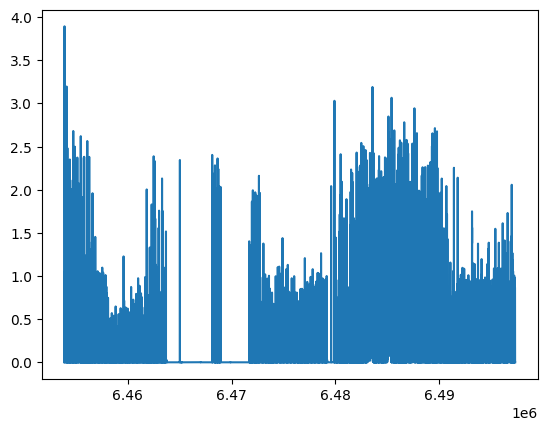

In [350]:
df_single.Heat_Pump_Energy_Output_Diff.plot()

In [351]:

# 1. Drop columns with almost all missing data (e.g., more than 90% missing)
threshold = 0.3 * len(df_single)
df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
#print("Columns dropped due to high missing values:")
#print(df_single.columns.difference(df_single_cleaned.columns).tolist())

In [352]:
df_single_cleaned

,Unnamed: 0,Property_ID,Timestamp,half-hour,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,...,temp,humidity,windspeed,solarradiation,pressure,visibility,cloudcover,Heat_Pump_Energy_Output_Diff,Internal_Temperature_Diff,Internal_Ambient_Temperature_Diff
6453884,6453884,EOH2034,2021-04-07 15:30:00,15:30:00,NaN,NaN,NaN,NaN,NaN,19.22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6453885,6453885,EOH2034,2021-04-07 16:00:00,16:00:00,NaN,NaN,NaN,5.55,18.85,19.01,...,6.00,41.930,17.20,299.0,1021.00,19.70,84.00,NaN,NaN,NaN
6453886,6453886,EOH2034,2021-04-07 16:30:00,16:30:00,NaN,NaN,NaN,5.45,18.70,18.79,...,5.95,42.160,14.85,226.0,1021.00,18.95,84.00,NaN,NaN,-11.11
6453887,6453887,EOH2034,2021-04-07 17:00:00,17:00:00,NaN,NaN,NaN,5.33,18.47,18.64,...,5.90,42.390,12.50,153.0,1021.00,18.20,84.00,NaN,-0.23,-11.00
6453888,6453888,EOH2034,2021-04-07 17:30:00,17:30:00,NaN,NaN,NaN,5.18,18.49,18.80,...,5.90,41.090,10.40,141.0,1020.55,18.20,56.10,NaN,0.22,-11.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6497288,6497288,EOH2034,2023-09-28 21:30:00,21:30:00,132.309,4295.243,2463.141,12.89,25.66,34.65,...,13.80,78.265,10.40,0.0,1005.95,11.20,39.95,0.0,0.00,-7.24
6497289,6497289,EOH2034,2023-09-28 22:00:00,22:00:00,132.309,4295.243,2463.150,12.90,25.51,34.45,...,13.80,78.090,9.70,0.0,1005.90,11.60,39.20,0.0,0.00,-7.23
6497290,6497290,EOH2034,2023-09-28 22:30:00,22:30:00,132.309,4295.243,2463.159,13.05,25.39,34.30,...,13.80,80.565,7.90,0.0,1005.90,11.60,39.95,0.0,0.00,-7.08
6497291,6497291,EOH2034,2023-09-28 23:00:00,23:00:00,132.309,4295.243,2463.167,12.97,25.27,34.11,...,13.80,83.040,6.10,0.0,1005.90,11.60,40.70,0.0,-0.08,-7.08


RMSE of q_hp: 38.32030483025769


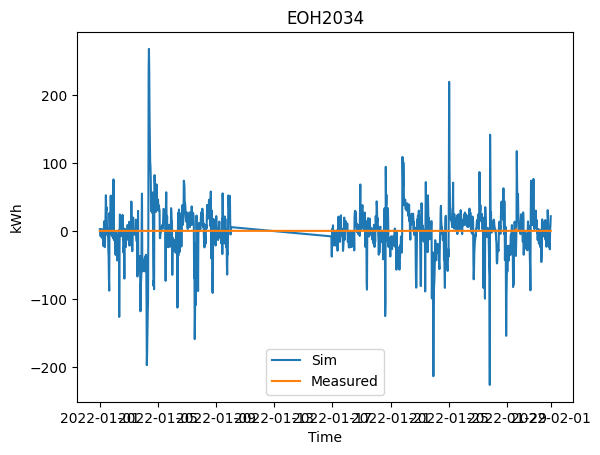

In [353]:

#print("\nColumns remaining after dropping highly missing columns:")
#print(df_single.columns.tolist())

# 2. Handle missing values: Interpolate if missing for up to 2 hours (4 half-hour intervals), else drop rows
df_single_cleaned = df_single_cleaned.set_index('Timestamp')
df_single_cleaned = df_single_cleaned.sort_index()

# Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
numeric_cols = df_single_cleaned.select_dtypes(include=['number']).columns
df_single_numeric_interpolated = df_single_cleaned[numeric_cols].interpolate(method='time', limit=4, limit_direction='both')

df_single_interpolated = df_single_cleaned.copy()
df_single_interpolated[numeric_cols] = df_single_numeric_interpolated

# After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
initial_rows = len(df_single_interpolated)
df_single_processed = df_single_interpolated.dropna()
rows_dropped_after_interpolation = initial_rows - len(df_single_processed)

#print(f"\nNumber of rows dropped after handling NA values (missing for >
# 2 hours): {rows_dropped_after_interpolation}")

# -----EXTRACT SUMMER DATA -------#
df_heating_single = df_single_processed.copy()

t_start = t_start_val
t_end = t_end_val
df_q_opt = df_q_results[(df_q_results.index>=t_start_train) & (df_q_results
                                                          .index<=t_end_train)]
df_heating_val = df_heating_single[df_heating_single.index>=t_start]
df_heating_val = df_heating_val[df_heating_val.index<=t_end]

# make sure you have an Hour column
df_heating_val = df_heating_val.assign(Hour=df_heating_val.index.hour)

# define night‑time & zero‑solar conditions
night_time = (df_heating_val['Hour'] >= 22) | (df_heating_val['Hour'] < 6)
zero_solar = (df_heating_val['solarradiation'] == 0)

# vectorized assignment of w
df_heating_val['w'] = np.where(night_time & zero_solar, w_n, 0.0)

w = df_heating_val['w'].iloc[:-1].reset_index(drop=True).to_numpy()

T_a_val = (df_heating_val["External_Air_Temperature"].iloc[:-1].reset_index
       (drop=True).to_numpy())
T_i_val = (df_heating_val["Internal_Air_Temperature"].iloc[:-1].reset_index
       (drop=True).to_numpy())
delta_T_a_val = (df_heating_val["Internal_Ambient_Temperature_Diff"].iloc[:-1]
             .reset_index(drop=True).to_numpy())
delta_T_i_val = (df_heating_val["Internal_Temperature_Diff"].iloc[1:]
             .reset_index(drop=True).to_numpy() / delta_t)
q_hp_val = (df_heating_val["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
        .reset_index(drop=True).to_numpy())
q_solar_val = (df_heating_val["solarradiation"].iloc[:-1].reset_index
           (drop=True).to_numpy())
v_wind_val = (df_heating_val["windspeed"].iloc[:-1].reset_index(drop=True)
          .to_numpy())



q_hat_sim = (delta_T_i_val * C -  delta_T_a_val / R_a * delta_t  - w_s *
        q_solar_val  - w * np.ones(len(T_a_val), )* delta_t )

e_q = q_hat_sim - q_hp_val
rmse_q_val = np.sqrt(np.mean(e_q**2))
print(f"RMSE of q_hp: {rmse_q_val}")

plt.plot(df_heating_val.index[1:],q_hat_sim, label = "Sim")
plt.plot(df_heating_val.index[1:], q_hp_val, label = "Measured")
plt.legend()
plt.xlabel("Time")
plt.ylabel("kWh")
plt.title(f"{id_use}")
plt.show()

<Axes: xlabel='Timestamp'>

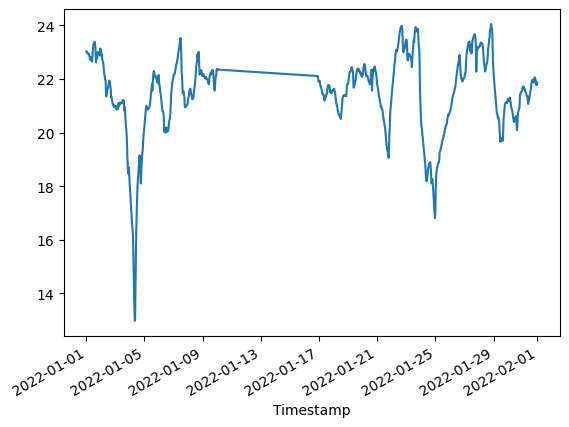

In [356]:
df_heating_val["Internal_Air_Temperature"].plot()

In [355]:
# ------- Look at heat supply performance in validation data ------

for id_use in unique_ids:
    df_id = trained_params[id_use].copy()
    C = df_id.C
    R_a = df_id.R_a
    w_s= df_id.w_s
    w_n = df_id.w_n
    
    
    df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()
    
    #re-adjust Heat Pump Diff and add temp differences
    df_single["Heat_Pump_Energy_Output_Diff"] = df_single["Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single["Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] - 
         df_single["Internal_Air_Temperature"])
    
    # 1. Drop columns with almost all missing data (e.g., more than 90% missing)
    threshold = 0.90 * len(df_single)
    df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
    #print("Columns dropped due to high missing values:")
    #print(df_single.columns.difference(df_single_cleaned.columns).tolist())
    
    df_single = df_single_cleaned
    
    #print("\nColumns remaining after dropping highly missing columns:")
    #print(df_single.columns.tolist())
    
    # 2. Handle missing values: Interpolate if missing for up to 2 hours (4 half-hour intervals), else drop rows
    df_single = df_single.set_index('Timestamp')
    df_single = df_single.sort_index()
    
    # Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
    numeric_cols = df_single.select_dtypes(include=['number']).columns
    df_single_numeric_interpolated = df_single[numeric_cols].interpolate(method='time', limit=4, limit_direction='both')
    
    df_single_interpolated = df_single.copy() 
    df_single_interpolated[numeric_cols] = df_single_numeric_interpolated
    
    # After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
    initial_rows = len(df_single_interpolated)
    df_single_processed = df_single_interpolated.dropna()
    rows_dropped_after_interpolation = initial_rows - len(df_single_processed)
    
    #print(f"\nNumber of rows dropped after handling NA values (missing for >
    # 2 hours): {rows_dropped_after_interpolation}")
    
    # -----EXTRACT SUMMER DATA -------# 
    df_heating_single = df_single_processed.copy()
    
    t_start = pd.to_datetime("2023 01 01 00:00:00")
    t_end = pd.to_datetime("2023 01 05 23:59:00")
    df_q_opt = df_q_results[(df_q_results.index>=t_start) & (df_q_results.index<=t_end)]
    df_heating_val = df_heating_single[df_heating_single.index>=t_start]
    df_heating_val = df_heating_val[df_heating_val.index<=t_end]
    
    # make sure you have an Hour column
    df_heating_val = df_heating_val.assign(Hour=df_heating_val.index.hour)
    
    # define night‑time & zero‑solar conditions
    night_time = (df_heating_val['Hour'] >= 22) | (df_heating_val['Hour'] < 6)
    zero_solar = (df_heating_val['SolarRadiation'] == 0)
    
    # vectorized assignment of w
    df_heating_val['w'] = np.where(night_time & zero_solar, w_n, 0.0)
    
    w = df_heating_val['w'].iloc[:-1].reset_index(drop=True).to_numpy()
    
    T_a_val = (df_heating_val["External_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    T_i_val = (df_heating_val["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    delta_T_a_val = (df_heating_val["Internal_Ambient_Temperature_Diff"].iloc[:-1]
                 .reset_index(drop=True).to_numpy()) 
    delta_T_i_val = (df_heating_val["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t) 
    q_hp_val = (df_heating_val["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy()) 
    q_solar_val = (df_heating_val["SolarRadiation"].iloc[:-1].reset_index
               (drop=True).to_numpy()) 
    v_wind_val = (df_heating_val["Windspeed"].iloc[:-1].reset_index(drop=True)
              .to_numpy()) 
    
    
    
    q_hat_sim = (delta_T_i_val * C -  delta_T_a_val / R_a * delta_t  - w_s *  
            q_solar_val  - w * np.ones(len(T_a_val), )* delta_t )
    
    e_q = q_hat_sim - q_hp_val
    rmse_q_val = np.sqrt(np.mean(e_q**2))
    print(f"RMSE of q_hp: {rmse_q_val}")
    
    plt.plot(df_heating_val.index[1:],q_hat_sim, label = "Sim")
    plt.plot(df_heating_val.index[1:], q_hp_val, label = "Measured")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("kWh")
    plt.title(f"{id_use}")
    plt.show()

KeyError: 'EOH0005'

In [ ]:
# -----Look at temperature tracking performance in the training --------------

for id_use in unique_ids:
    df_id = trained_params[id_use].copy()
    C = df_id.C
    R_a = df_id.R_a
    w_s= df_id.w_s
    w_n = df_id.w_n
    
    df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()
    
    #re-adjust Heat Pump Diff and add temp differences
    df_single["Heat_Pump_Energy_Output_Diff"] = df_single["Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single["Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] - 
         df_single["Internal_Air_Temperature"])
         
    
    
    # 1. Drop columns with almost all missing data (e.g., more than 90% missing)
    threshold = 0.90 * len(df_single)
    df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
    #print("Columns dropped due to high missing values:")
    #print(df_single.columns.difference(df_single_cleaned.columns).tolist())
    
    df_single = df_single_cleaned
    
    #print("\nColumns remaining after dropping highly missing columns:")
    #print(df_single.columns.tolist())
    
    # 2. Handle missing values: Interpolate if missing for up to 2 hours (4 half-hour intervals), else drop rows
    df_single = df_single.set_index('Timestamp')
    df_single = df_single.sort_index()
    
    # Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
    numeric_cols = df_single.select_dtypes(include=['number']).columns
    df_single_numeric_interpolated = df_single[numeric_cols].interpolate(method='time', limit=4, limit_direction='both')
    
    df_single_interpolated = df_single.copy() 
    df_single_interpolated[numeric_cols] = df_single_numeric_interpolated
    
    # After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
    initial_rows = len(df_single_interpolated)
    df_single_processed = df_single_interpolated.dropna()
    rows_dropped_after_interpolation = initial_rows - len(df_single_processed)
    
    #print(f"\nNumber of rows dropped after handling NA values (missing for >
    # 2 hours): {rows_dropped_after_interpolation}")
    
    # -----EXTRACT SUMMER DATA -------# 
    df_heating_single = df_single_processed.copy()
    
    # Validate results
    t_start = pd.to_datetime("2022 01 01 00:00:00")
    t_end = pd.to_datetime("2022 01 02 23:59:00")
    df_q_id_use = df_q_id[(df_q_id.index>=t_start) & (df_q_id.index<=t_end)]
    df_heating_val = df_heating_single[df_heating_single.index>=t_start]
    df_heating_val = df_heating_val[df_heating_val.index<=t_end]
    
    # make sure you have an Hour column
    df_heating_val = df_heating_val.assign(Hour=df_heating_val.index.hour)
    
    # define night‑time & zero‑solar conditions
    night_time = (df_heating_val['Hour'] >= 22) | (df_heating_val['Hour'] < 6)
    zero_solar = (df_heating_val['SolarRadiation'] == 0)
    
    # vectorized assignment of w
    df_heating_val['w'] = np.where(night_time & zero_solar, w_n, 0.0)
    
    w = df_heating_val['w'].iloc[:-1].reset_index(drop=True).to_numpy()
    
    T_a_val = (df_heating_val["External_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    T_i_val = (df_heating_val["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    delta_T_a_val = (df_heating_val["Internal_Ambient_Temperature_Diff"].iloc[:-1]
                 .reset_index(drop=True).to_numpy()) 
    delta_T_i_val = (df_heating_val["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t) 
    q_hp_val = (df_heating_val["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy()) 
    q_solar_val = (df_heating_val["SolarRadiation"].iloc[:-1].reset_index
               (drop=True).to_numpy()) 
    v_wind_val = (df_heating_val["Windspeed"].iloc[:-1].reset_index(drop=True)
              .to_numpy()) 
    
    
    delta_T_i_sim = (delta_T_a_val / R_a *delta_t + q_hp_val + w_s* q_solar_val+ w * np
                     .ones(len(T_a_val), )* delta_t) / C
    
    T_i_sim = np.zeros_like(T_i_val)
    T_i_prev = T_i_val[0]
    for i in range(len(delta_T_i_sim)):
        T_i_sim[i] = T_i_prev + delta_T_i_sim[i]*delta_t
        T_i_prev = T_i_sim[i]
    
    
    plt.plot(df_heating_val.index[1:],delta_T_i_sim, label = "Sim")
    plt.plot(df_heating_val.index[1:], delta_T_i_val, label = "Measured")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Delta T")
    plt.title(f"{id_use}")
    plt.show()
    
    plt.plot(df_heating_val.index[1:],T_i_sim, label = "Sim")
    plt.plot(df_heating_val.index[1:], df_heating_val["Internal_Air_Temperature"]
             .iloc[1:].reset_index
           (drop=True).to_numpy(), label = "Measured")
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Celsius")
    plt.title(f"{id_use}")
    plt.show()